In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.constants import c
c_in_Mpc_sec = c.to('Mpc/s').value

import sys
sys.path.append('../')
sys.path.append('../crisp-py')

from core import *

In [3]:
from data.nucleardecays import *
ndt = NuclearDataTable('../data/nubase2016.txt')
decdict = ndt.prepare_decay_table()
decaydata = nuclear_data_parser('../data/nubase2016.txt')

# Some decays from available data 

In [ ]:
from particle import Particle

getZA = lambda nucid: (nucid % 100, nucid // 100)
getnum = lambda num: str(num) if num > 1 else ''
getlabel = lambda nucid: Particle.from_nucleus_info(*getZA(nucid)) if nucid not in [-1, 1] else Particle.from_pdgid(np.sign(nucid)*11)

decays = []
for nuc, decdata in decdict.items():
    if nuc > 5728:
        continue
    for chan in decdata['channels']:
        count_prod = [(chan[1:].count(dau), dau) for dau in sorted(set(chan[1:]))]
        decays += [getnum(cnt) + getlabel(prod).latex_name for cnt, prod in count_prod]

dlabels = list(set(decays))

Text(0.5, 1.0, 'Disintegration products for nuclei ')

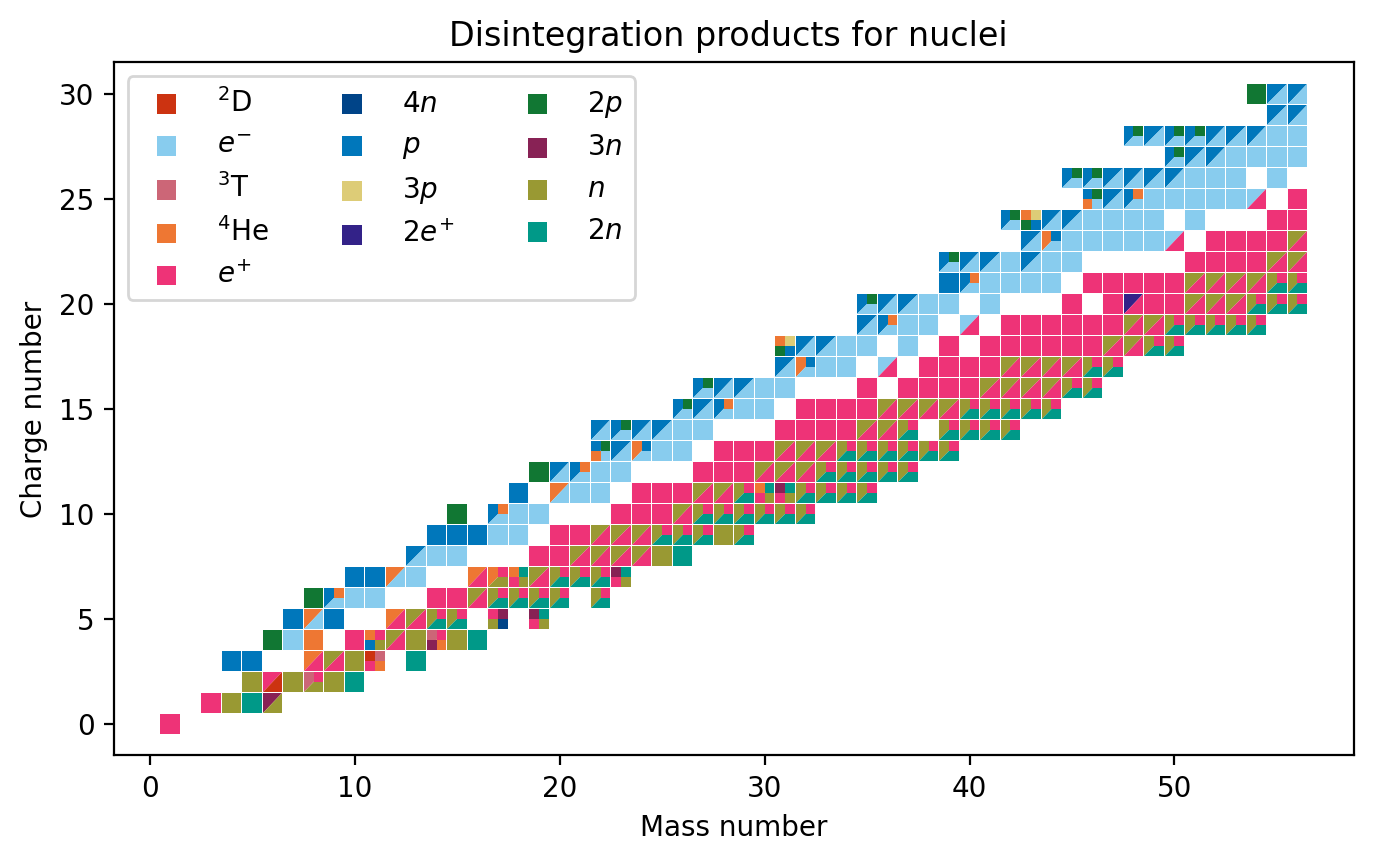

In [ ]:
plt.subplots(figsize=(8.5, 4.5), dpi=200)

colors = ['#CC3311', '#88CCEE', '#CC6677', '#EE7733', '#EE3377', '#004488', 
          '#0077BB', '#DDCC77', '#332288', '#117733', '#882255', '#999933', '#009988']

lab_to_color = dict([(dl, col) for dl, col in zip(dlabels, colors)])

for k, (dlab, col) in enumerate(zip(dlabels, colors[:])):
    plt.scatter([], [], marker='s', s=50, color=col, ec='none', label=r''.join(['$', dlab, '$']))
plt.legend(ncol=3)

def set_color(chans):
    decays = []

    for chan in chans:
        count_prod = [(chan[1:].count(dau), dau) for dau in sorted(set(chan[1:]))]
        decays += [getnum(cnt) + getlabel(prod).latex_name for cnt, prod in count_prod]
    
    colors = [lab_to_color[lab] for lab in set(decays)]

    return colors

for nuc, decdata in decdict.items():
    if nuc > 5728:
        continue
    chans = decdata['channels']
    color = set_color(chans)
    
    if len(color) == 1:
        plt.scatter(nuc//100, nuc % 100, marker='s', s=50, color=color[0], ec='none')
    else:
        marker = [
            [[-1, -1], [-1, 1], [1, 1]], 
            [[-1, -1], [1, -1], [1, 1]], 
            [[0, 1], [1, 1], [1, 0], [0, 0]], 
            [[-1, 0], [0, 0], [0, -1], [-1, -1]]]
        for k, (mk, col) in enumerate(zip(marker, color)):
            plt.scatter(nuc//100, nuc % 100, marker=mk, s=50, color=col, ec='none')

plt.xlabel('Mass number')
plt.ylabel('Charge number')
plt.title('Disintegration products for nuclei ')

# Decay rates compared to photomeson rates

In [ ]:
from interaction_rates import cs_photomeson, interaction_rate_from_cross_section
from scipy.constants import c, parsec
from background_photon_models import cmb_photon_density_GeVcm3

def get_photomeson_rates(boosts, Z, A):
    eps = np.logspace(-1, 5, 200)
    pdis_rates = interaction_rate_from_cross_section(br * A * .939, A, cmb_photon_density_GeVcm3, eps, cs_photomeson(eps, A))
    pdis_rates /= c / parsec / 1e6 # ito Mpc

    return pdis_rates

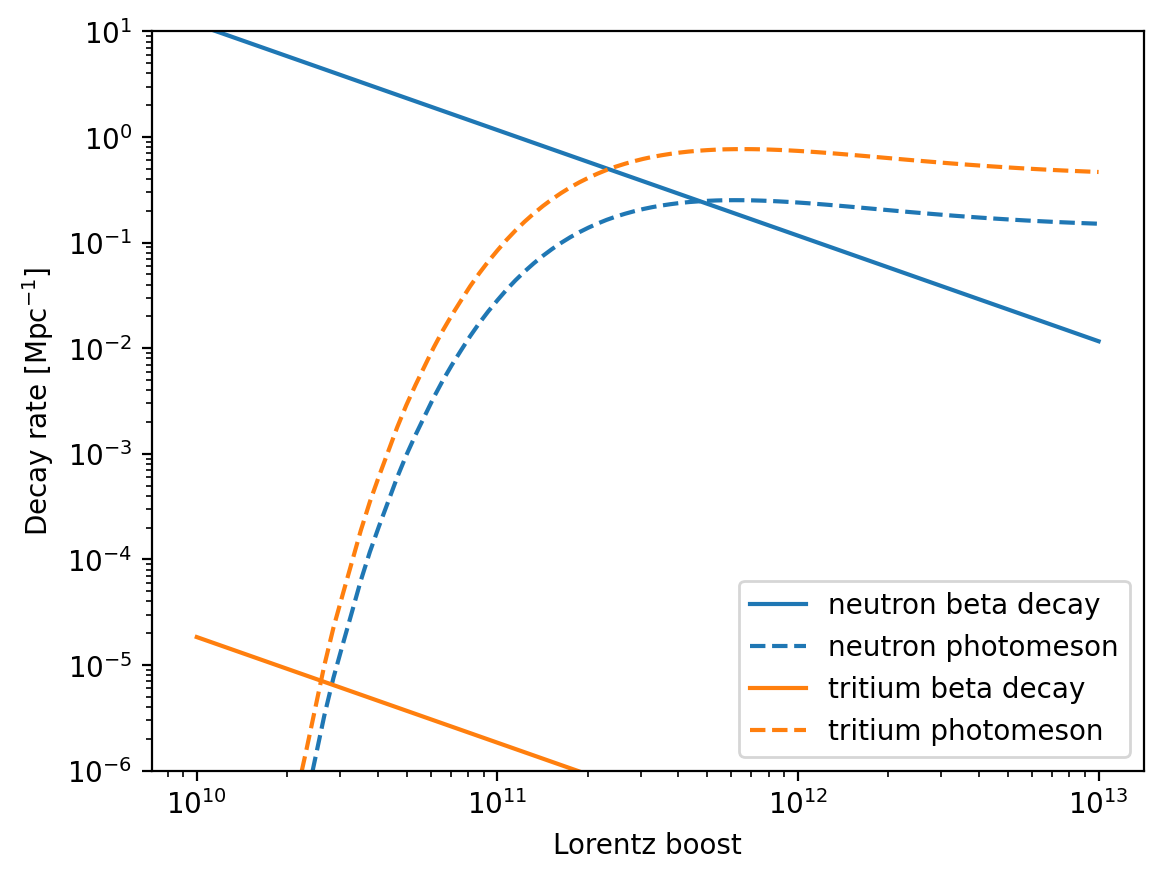

In [ ]:
plt.subplots(dpi=200)

br = np.logspace(10, 13, 100)

tau = decdict[100]['decay_time']
plt.loglog(br, 1/(br * tau * c_in_Mpc_sec), label='neutron beta decay')
plt.loglog(br, get_photomeson_rates(br, 0, 1), label='neutron photomeson', c='C0', ls='--')


tau = decdict[301]['decay_time']
plt.loglog(br, 1/(br * tau * c_in_Mpc_sec), label='tritium beta decay')
plt.loglog(br, get_photomeson_rates(br, 1, 3), label='tritium photomeson', c='C1', ls='--')


plt.xlabel('Lorentz boost')
plt.ylabel('Decay rate [Mpc$^{-1}$]')
plt.ylim([1e-6, 10])
plt.legend()